# Regressão Linear com PyTorch - Dataset House Sales

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/harlfoxem/housesalesprediction).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [149]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [150]:
#!/bin/bash
#!curl -L -o /content/housesalesprediction.zip\
#  https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction

In [151]:
!ls #pra executar comandos linux precisa colocar a "!"

housesalesprediction.zip  kc_house_data.csv  sample_data


In [152]:
#!unzip /content/housesalesprediction.zip #precisa deszipar pra criar o arquivo .csv

In [198]:
# Load the dataset
df = pd.read_csv('kc_house_data.csv') #lendo o csv com o pandas

In [199]:
df.shape

(21613, 21)

In [200]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [201]:
#remove as colunas id e date que não influencia no valor da casa
df = df.drop(['id', 'date'], axis=1)

In [202]:
# no X deve salvar todas as colunas exceto price que é o valor que devemos prever
X = df.drop('price', axis=1)
y = df[['price']].values

In [203]:
X[0:5] #features das casas

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [204]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       21613 non-null  int64  
 1   bathrooms      21613 non-null  float64
 2   sqft_living    21613 non-null  int64  
 3   sqft_lot       21613 non-null  int64  
 4   floors         21613 non-null  float64
 5   waterfront     21613 non-null  int64  
 6   view           21613 non-null  int64  
 7   condition      21613 non-null  int64  
 8   grade          21613 non-null  int64  
 9   sqft_above     21613 non-null  int64  
 10  sqft_basement  21613 non-null  int64  
 11  yr_built       21613 non-null  int64  
 12  yr_renovated   21613 non-null  int64  
 13  zipcode        21613 non-null  int64  
 14  lat            21613 non-null  float64
 15  long           21613 non-null  float64
 16  sqft_living15  21613 non-null  int64  
 17  sqft_lot15     21613 non-null  int64  
dtypes: flo

In [205]:
y #preço das casas

array([[221900.],
       [538000.],
       [180000.],
       ...,
       [402101.],
       [400000.],
       [325000.]])

In [206]:
y.shape

(21613, 1)

In [207]:
X.shape

(21613, 18)

In [208]:
X.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

### Normalização dos dados

In [209]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [210]:
# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32) #torch.FloatTensor
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 18])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 18])
y_val_tensor shape: torch.Size([6484, 1])


## Criação do modelo da rede

In [211]:
model = torch.nn.Linear(X_train_tensor.shape[1], 1) # define o modelo considerando todas as features de X_train_tensor

### Verificando a inicialização dos parâmetros

In [212]:
model.weight.data

tensor([[ 0.0477, -0.0922, -0.1156,  0.0610,  0.2199,  0.1131, -0.0228, -0.0114,
          0.1340, -0.1638,  0.0784, -0.0781,  0.1364, -0.0841,  0.0117,  0.0796,
          0.1620, -0.0346]])

### Testando o predict da rede

In [213]:
# Test the model's prediction with a dummy input of correct shape (5 samples, 20 features)
model(torch.ones(5, X_train_tensor.shape[1]))

tensor([[0.6560],
        [0.6560],
        [0.6560],
        [0.6560],
        [0.6560]], grad_fn=<AddmmBackward0>)

In [214]:
model(X_train_tensor[0:5])

tensor([[0.5371],
        [0.0448],
        [0.3452],
        [0.9415],
        [0.3741]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [215]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
num_epochs = 120

### Laço de treinamento

In [216]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train) #predict
    loss = criterion(outputs, y_train)  #calculo das perdas

    # Backward and optimize (atualização dos pesos)
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value (retorna o valor da perda)

In [217]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

**Obs:** X_train e X_val influenciam os pesos, mas X_val e y_val não influenciam

In [218]:
train_losses = [] #perdas de treinamento
val_losses = [] #perdas de validação

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # verbose
    if (epoch + 1) % 10 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[10/120], Train Loss: 0.324657, Val Loss: 0.347866
Epoch[20/120], Train Loss: 0.301729, Val Loss: 0.328777
Epoch[30/120], Train Loss: 0.294952, Val Loss: 0.323507
Epoch[40/120], Train Loss: 0.292602, Val Loss: 0.321987
Epoch[50/120], Train Loss: 0.291761, Val Loss: 0.321635
Epoch[60/120], Train Loss: 0.291455, Val Loss: 0.321625
Epoch[70/120], Train Loss: 0.291343, Val Loss: 0.321694
Epoch[80/120], Train Loss: 0.291301, Val Loss: 0.321764
Epoch[90/120], Train Loss: 0.291286, Val Loss: 0.321818
Epoch[100/120], Train Loss: 0.291280, Val Loss: 0.321855
Epoch[110/120], Train Loss: 0.291278, Val Loss: 0.321880
Epoch[120/120], Train Loss: 0.291277, Val Loss: 0.321895


**Melhorias: 1) verificar a época a partir da qual os valores se estabilizam (melhor época). 2) "paciência" - esperar determinada qtn de épocas, e se a partir dali os pesos não tiverem uma alteração significativa, poderia interromper o treinamento.**

## Avaliação

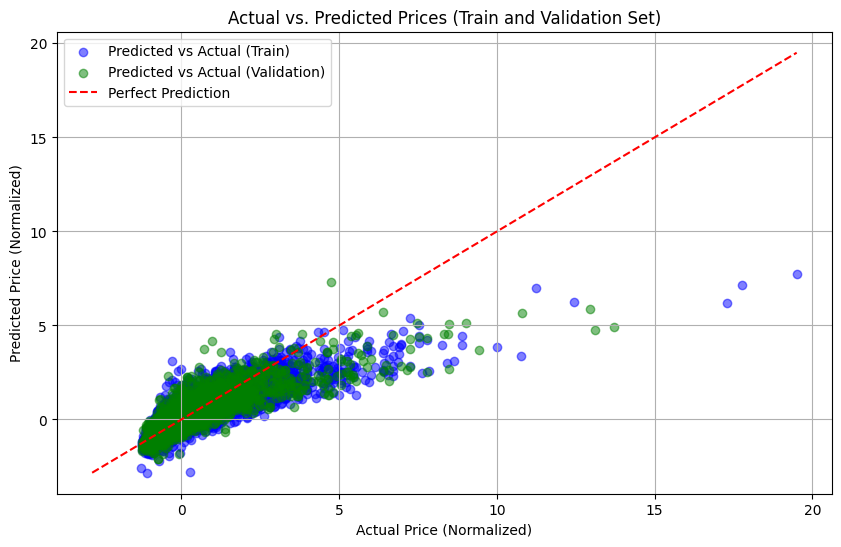

In [219]:
y_pred_train = model(X_train_tensor)
y_pred_val = model(X_val_tensor)

plt.figure(figsize=(10, 6))

# Plot predicted vs actual for Training Data
plt.scatter(y_train_tensor.numpy(), y_pred_train.data.numpy(), alpha=0.5, label='Predicted vs Actual (Train)', color='blue')

# Plot predicted vs actual for Validation Data
plt.scatter(y_val_tensor.numpy(), y_pred_val.data.numpy(), alpha=0.5, label='Predicted vs Actual (Validation)', color='green')

# Plot a perfect prediction line (y=x)
max_val = max(y_val_tensor.max(), y_pred_val.max(), y_train_tensor.max(), y_pred_train.max()).item()
min_val = min(y_val_tensor.min(), y_pred_val.min(), y_train_tensor.min(), y_pred_train.min()).item()
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Price (Normalized)')
plt.ylabel('Predicted Price (Normalized)')
plt.title('Actual vs. Predicted Prices (Train and Validation Set)')
plt.legend()
plt.grid(True)
plt.show()

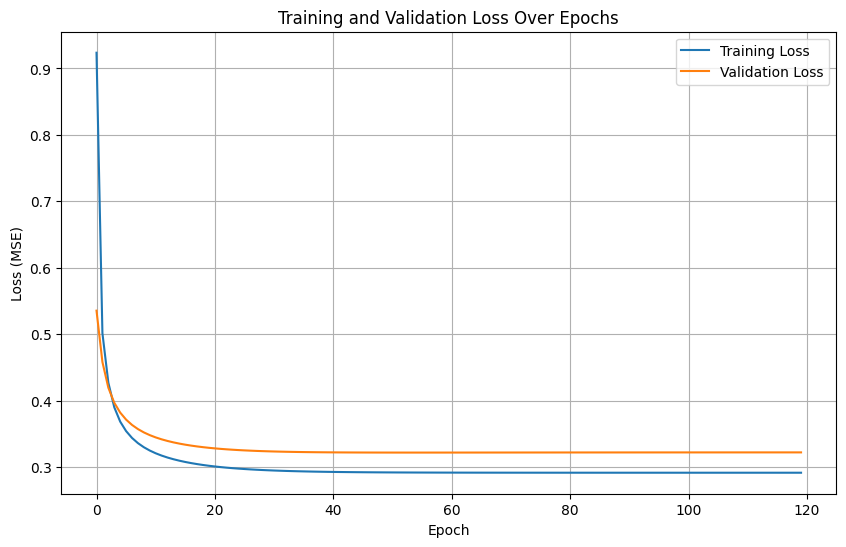

In [220]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()